<a href="https://colab.research.google.com/github/JOk3r01001/Fracture_detection_efficientnetB1-focal_loss/blob/main/Grad_cam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive



drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import shutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt

# Paths and parameters
BASE_PATH   = "/content/drive/MyDrive/BK2.0/FracAtlas2/images"
LOCAL_KERAS = "/content/keras_data"
IMG_SIZE    = (640, 640)
BATCH_SIZE  = 8
SEED        = 42

# 1. Build dataframe directly from folder structure
records = []
for label_name, label_val in [("Fractured", 1), ("Non_fractured", 0)]:
    folder = os.path.join(BASE_PATH, label_name)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg')):
            records.append({
                "img_name": fname,
                "filepath": os.path.join(folder, fname),
                "label":    label_val,
                "label_str": str(label_val)
            })

df = pd.DataFrame(records)
print(f"Total images: {len(df)}  |  Fractured: {df['label'].sum()}  |  Non_fractured: {(df['label']==0).sum()}")

# 2. Detect and remove corrupted images
def remove_corrupted(df, name):
    bad = []
    for idx, row in df.iterrows():
        try:
            with Image.open(row['filepath']) as img:
                img.verify()
        except Exception:
            bad.append(idx)
            print(f"  Corrupted: {row['img_name']}")
    print(f"{name}: removed {len(bad)} corrupted images")
    return df.drop(bad).reset_index(drop=True)

df = remove_corrupted(df, "ALL")

# 3. Stratified split 80 / 10 / 10
train_df, tmp_df = train_test_split(df,     test_size=0.20, stratify=df['label'],     random_state=SEED)
val_df,  test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df['label'], random_state=SEED)

print(f"\nAfter split:")
print(f"  Train : {len(train_df)}  (frac={train_df['label'].mean():.2f})")
print(f"  Val   : {len(val_df)}   (frac={val_df['label'].mean():.2f})")
print(f"  Test  : {len(test_df)}  (frac={test_df['label'].mean():.2f})")

# Copy images to local environment for faster data loading
for split in ['train', 'val', 'test']:
    for cls in ['Fractured', 'Non_fractured']:
        os.makedirs(os.path.join(LOCAL_KERAS, split, cls), exist_ok=True)

def copy_to_local(df, split_name):
    print(f"Copying {split_name}...")
    for _, row in df.iterrows():
        folder = 'Fractured' if row['label'] == 1 else 'Non_fractured'
        dst = os.path.join(LOCAL_KERAS, split_name, folder, row['img_name'])
        if not os.path.exists(dst):
            shutil.copy(row['filepath'], dst)
    print(f"  Done: {len(df)} images")

copy_to_local(train_df, 'train')
copy_to_local(val_df,   'val')
copy_to_local(test_df,  'test')

# Update file paths to local environment
def local_path(row, split):
    folder = 'Fractured' if row['label'] == 1 else 'Non_fractured'
    return os.path.join(LOCAL_KERAS, split, folder, row['img_name'])

train_df['filepath'] = train_df.apply(lambda r: local_path(r, 'train'), axis=1)
val_df['filepath']   = val_df.apply(lambda r: local_path(r, 'val'),   axis=1)
test_df['filepath']  = test_df.apply(lambda r: local_path(r, 'test'),  axis=1)

print("\nAll data copied locally")

# Data generators with augmentation for training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    horizontal_flip=True,
    rotation_range=15,
    fill_mode='nearest'
)
# Validation and test generators - preprocessing only
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_gen(datagen, df, shuffle):
    return datagen.flow_from_dataframe(
        df,
        x_col='filepath',
        y_col='label_str',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=['0', '1'],
        shuffle=shuffle
    )

train_gen = make_gen(train_datagen, train_df, shuffle=True)
val_gen   = make_gen(val_datagen,   val_df,   shuffle=False)
test_gen  = make_gen(val_datagen,   test_df,  shuffle=False)

print("\nGenerators are ready")
print(f"  Train batches : {len(train_gen)}")
print(f"  Val batches   : {len(val_gen)}")
print(f"  Test batches  : {len(test_gen)}")

Total images: 4083  |  Fractured: 717  |  Non_fractured: 3366
ALL: removed 0 corrupted images

After split:
  Train : 3266  (frac=0.18)
  Val   : 408   (frac=0.17)
  Test  : 409  (frac=0.18)
Copying train...
  Done: 3266 images
Copying val...
  Done: 408 images
Copying test...
  Done: 409 images

All data copied locally
Found 3266 validated image filenames belonging to 2 classes.
Found 408 validated image filenames belonging to 2 classes.
Found 409 validated image filenames belonging to 2 classes.

Generators are ready
  Train batches : 409
  Val batches   : 51
  Test batches  : 52


In [3]:

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from PIL import Image
import cv2

# Output directory for model weights and logs
PROJECT_OUT = "/content/drive/MyDrive/Keras_gradcam"
os.makedirs(PROJECT_OUT, exist_ok=True)

# Load pretrained EfficientNetB1 backbone without classification head
backbone = EfficientNetB1(
    include_top=False,
    weights='imagenet',
    input_shape=(640, 640, 3),
    name='efficientnetb1'
)
backbone.trainable = True

# Define custom classification head
inputs = keras.Input(shape=(640, 640, 3))
x = backbone(inputs, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# Focal loss - focuses training on hard misclassified examples
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss

# Compile model
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.0005),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================
# Grad-CAM helper functions
# =========================

def find_last_conv_layer(model):
    """
    Finds the last Conv2D layer in the model (including nested backbone).
    """
    # First check inside backbone, because EfficientNet is nested in the full model
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

    # Fallback: search in the full model
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

    raise ValueError("No Conv2D layer found in model.")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Creates Grad-CAM heatmap for a single preprocessed image batch of shape (1, H, W, 3).
    """
    # Build a model mapping input -> last conv output + model output
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer('efficientnetb1').get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array, training=False)

        # Binary classification with sigmoid output
        if pred_index is None:
            class_channel = preds[:, 0]
        else:
            class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling over feature map gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]  # (H, W, C)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :], axis=-1)

    # ReLU and normalization
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()


def load_and_preprocess_image(img_path, img_size=(640, 640)):
    """
        Loads image for both display and model input.
        Returns:
        original_img_rgb : original image in RGB
        img_array        : preprocessed batch tensor (1, H, W, 3)
    """
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    original_img_rgb = img_array.astype(np.uint8)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return original_img_rgb, img_array


def overlay_gradcam(original_img, heatmap, alpha=0.4):
    """
    Overlays heatmap onto original RGB image.
    """
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(original_img, 1 - alpha, heatmap_color, alpha, 0)
    return heatmap, superimposed_img


def show_gradcam(img_path, model, img_size=(640, 640), alpha=0.4):
    """
    Runs prediction + Grad-CAM and displays:
    original image, heatmap, overlay
    """
    last_conv_layer_name = find_last_conv_layer(model)
    print(f"Using last conv layer: {last_conv_layer_name}")

    original_img, img_array = load_and_preprocess_image(img_path, img_size=img_size)

    pred = model.predict(img_array, verbose=0)[0][0]
    pred_label = "Fracture" if pred > 0.5 else "No Fracture"
    confidence = pred if pred > 0.5 else 1 - pred

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name=last_conv_layer_name
    )

    heatmap_gray, overlay = overlay_gradcam(original_img, heatmap, alpha=alpha)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_gray, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPrediction: {pred_label} ({confidence:.3f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def save_gradcam(img_path, model, save_path, img_size=(640, 640), alpha=0.4):
    last_conv_layer_name = find_last_conv_layer(model)

    original_img, img_array = load_and_preprocess_image(img_path, img_size=img_size)

    pred = model.predict(img_array, verbose=0)[0][0]
    pred_label = "Fracture" if pred > 0.5 else "No Fracture"
    confidence = pred if pred > 0.5 else 1 - pred

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name=last_conv_layer_name
    )

    heatmap_gray, overlay = overlay_gradcam(original_img, heatmap, alpha=alpha)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_gray, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPrediction: {pred_label} ({confidence:.3f})")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

# Callbacks for training control
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_recall',
        patience=10,
        mode='max',
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(PROJECT_OUT, 'efficientnet_best.keras'),
        monitor='val_recall',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(PROJECT_OUT, 'efficientnet_training_log.csv')
    )
]

# Train model on training data with validation
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
)



27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 20, 20, 1280)   │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,941,320 (26.48 MB)

 Trainable params: 6,876,705 (26.23 MB)

 Non-trainable params: 64,615 (252.41 KB)

Epoch 1/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 641s 1s/step - accuracy: 0.7364 - auc: 0.5973 - loss: 0.0732 - precision: 0.2522 - recall: 0.2544 - val_accuracy: 0.7941 - val_auc: 0.6234 - val_loss: 0.0318 - val_precision: 0.3488 - val_recall: 0.2113 - learning_rate: 5.0000e-04
Epoch 2/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 424s 1s/step - accuracy: 0.7814 - auc: 0.6496 - loss: 0.0362 - precision: 0.3250 - recall: 0.2265 - val_accuracy: 0.8603 - val_auc: 0.8099 - val_loss: 0.0260 - val_precision: 0.7059 - val_recall: 0.3380 - learning_rate: 5.0000e-04
Epoch 3/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 423s 1s/step - accuracy: 0.8267 - auc: 0.7617 - loss: 0.0284 - precision: 0.5104 - recall: 0.3432 - val_accuracy: 0.8578 - val_auc: 0.8041 - val_loss: 0.0238 - val_precision: 0.6757 - val_recall: 0.3521 - learning_rate: 5.0000e-04
Epoch 4/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.8380 - auc: 0.7702 - loss: 0.0270 - precision: 0.5738 - recall: 0.3049 - val_accuracy: 0.8652 - val_auc: 0.8081 - val_lo

In [4]:
# Evaluate model on test set
print("\nTest set evaluation:")
results = model.evaluate(test_gen)
print(f"Accuracy:  {results[1]:.4f}")
print(f"Precision: {results[2]:.4f}")
print(f"Recall:    {results[3]:.4f}")
print(f"AUC:       {results[4]:.4f}")

test_gen.reset()
pred_probs = model.predict(test_gen)
preds = (pred_probs > 0.5).astype(int).ravel()

print("\nClassification Report:")
print(classification_report(
    test_gen.classes,
    preds,
    target_names=['No Fracture', 'Fracture']
))

# Confusion matrix to visualize correct and incorrect classifications
cm = confusion_matrix(test_gen.classes, preds)
print("\nConfusion Matrix:")
print(cm)



Test set evaluation:
52/52 ━━━━━━━━━━━━━━━━━━━━ 23s 448ms/step - accuracy: 0.8142 - auc: 0.8102 - loss: 0.0388 - precision: 0.4800 - recall: 0.6667
Accuracy:  0.8142
Precision: 0.4800
Recall:    0.6667
AUC:       0.8102
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 364ms/step

Classification Report:
              precision    recall  f1-score   support

 No Fracture       0.92      0.85      0.88       337
    Fracture       0.48      0.67      0.56        72

    accuracy                           0.81       409
   macro avg       0.70      0.76      0.72       409
weighted avg       0.84      0.81      0.83       409


Confusion Matrix:
[[285  52]
 [ 24  48]]
Using last conv layer: top_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_340']
Received: inputs=Tensor(shape=(1, 640, 640, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m131949584597792\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[233., 233., 233.],\n         [229., 229., 229.],\n         [229., 229., 229.],\n         ...,\n         [224., 224., 224.],\n         [224., 224., 224.],\n         [235., 235., 235.]],\n\n        [[233., 233., 233.],\n         [229., 229., 229.],\n         [229., 229., 229.],\n         ...,\n         [224., 224., 224.],\n         [224., 224., 224.],\n         [235., 235., 235.]],\n\n        [[231., 231., 231.],\n         [227., 227., 227.],\n         [227., 227., 227.],\n         ...,\n         [121., 121., 121.],\n         [121., 121., 121.],\n         [224., 224., 224.]],\n\n        ...,\n\n        [[233., 233., 233.],\n         [196., 196., 196.],\n         [196., 196., 196.],\n         ...,\n         [109., 109., 109.],\n         [109., 109., 109.],\n         [228., 228., 228.]],\n\n        [[235., 235., 235.],\n        

In [6]:
print(model)
print(backbone)
print(len(test_df))
print(IMG_SIZE)
print(PROJECT_OUT)

<Functional name=functional, built=True>
<Functional name=efficientnetb1, built=True>
409
(640, 640)
/content/drive/MyDrive/Keras_gradcam


In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2


# Grad-CAM helper functions


def find_last_conv_layer(backbone):
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in backbone.")


def build_classifier_head(model, backbone):
    """
    Creates a model mapping backbone output -> final prediction.
    """
    classifier_input = keras.Input(shape=backbone.output.shape[1:])
    x = classifier_input

    backbone_found = False
    for layer in model.layers:
        if layer.name == backbone.name:
            backbone_found = True
            continue
        if backbone_found:
            x = layer(x)

    classifier_model = keras.Model(classifier_input, x)
    return classifier_model


def make_gradcam_heatmap(img_array, model, backbone, last_conv_layer_name):
    """
    Grad-CAM for binary classification model with nested backbone.
    """
    last_conv_layer = backbone.get_layer(last_conv_layer_name)

    last_conv_model = keras.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    classifier_model = build_classifier_head(model, backbone)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_features = last_conv_model(img_array, training=False)
        tape.watch(conv_outputs)

        preds = classifier_model(backbone_features, training=False)
        class_channel = preds[:, 0]   # sigmoid binary output

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :], axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()


def load_and_preprocess_image(img_path, img_size=(640, 640)):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    original_img_rgb = img_array.astype(np.uint8)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return original_img_rgb, img_array


def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(original_img, 1 - alpha, heatmap_color, alpha, 0)
    return heatmap, superimposed_img


def show_gradcam(img_path, model, backbone, img_size=(640, 640), alpha=0.4):
    last_conv_layer_name = find_last_conv_layer(backbone)
    print(f"Using last conv layer: {last_conv_layer_name}")

    original_img, img_array = load_and_preprocess_image(img_path, img_size=img_size)

    pred = model.predict(img_array, verbose=0)[0][0]
    pred_label = "Fracture" if pred > 0.5 else "No Fracture"
    confidence = pred if pred > 0.5 else 1 - pred

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        backbone=backbone,
        last_conv_layer_name=last_conv_layer_name
    )

    heatmap_gray, overlay = overlay_gradcam(original_img, heatmap, alpha=alpha)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_gray, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPrediction: {pred_label} ({confidence:.3f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def save_gradcam(img_path, model, backbone, save_path, img_size=(640, 640), alpha=0.4):
    last_conv_layer_name = find_last_conv_layer(backbone)

    original_img, img_array = load_and_preprocess_image(img_path, img_size=img_size)

    pred = model.predict(img_array, verbose=0)[0][0]
    pred_label = "Fracture" if pred > 0.5 else "No Fracture"
    confidence = pred if pred > 0.5 else 1 - pred

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        backbone=backbone,
        last_conv_layer_name=last_conv_layer_name
    )

    heatmap_gray, overlay = overlay_gradcam(original_img, heatmap, alpha=alpha)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_gray, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPrediction: {pred_label} ({confidence:.3f})")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

Using last conv layer: top_conv


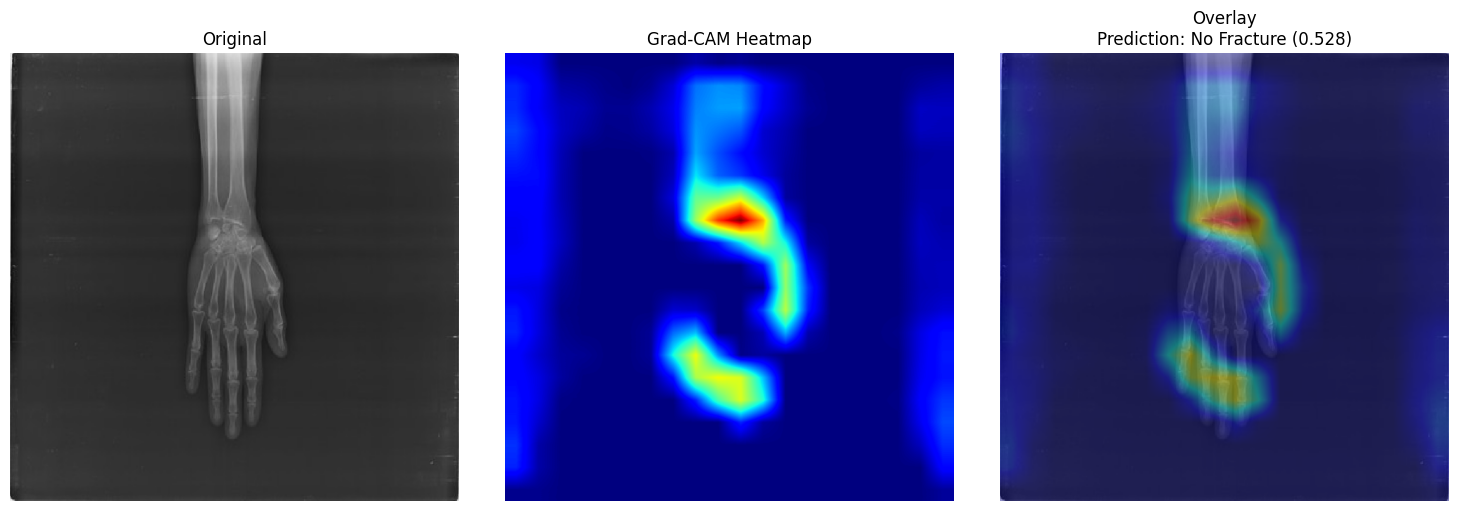

In [8]:
sample_img_path = test_df.iloc[0]['filepath']
show_gradcam(sample_img_path, model, backbone, img_size=IMG_SIZE, alpha=0.4)

In [9]:
GRADCAM_OUT = os.path.join(PROJECT_OUT, "gradcam_all_test")
os.makedirs(GRADCAM_OUT, exist_ok=True)

print(f"Generating Grad-CAM for {len(test_df)} test images...")

for i in range(len(test_df)):
    img_path = test_df.iloc[i]['filepath']
    img_name = os.path.splitext(os.path.basename(img_path))[0]
    true_label = test_df.iloc[i]['label']
    true_label_str = "Fracture" if true_label == 1 else "No Fracture"

    save_path = os.path.join(
        GRADCAM_OUT,
        f"{i:04d}_{true_label_str}_{img_name}_gradcam.png"
    )

    try:
        save_gradcam(
            img_path=img_path,
            model=model,
            backbone=backbone,
            save_path=save_path,
            img_size=IMG_SIZE,
            alpha=0.4
        )
        print(f"[{i+1}/{len(test_df)}] Saved: {save_path}")
    except Exception as e:
        print(f"[{i+1}/{len(test_df)}] Error for {img_path}: {e}")

print("Done.")

Generating Grad-CAM for 409 test images...
[1/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0000_No Fracture_IMG0002152_gradcam.png
[2/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0001_No Fracture_IMG0001474_gradcam.png
[3/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0002_Fracture_IMG0002474_gradcam.png
[4/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0003_No Fracture_IMG0002989_gradcam.png
[5/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0004_No Fracture_IMG0003817_gradcam.png
[6/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0005_No Fracture_IMG0000439_gradcam.png
[7/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0006_No Fracture_IMG0003656_gradcam.png
[8/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0007_Fracture_IMG0002402_gradcam.png
[9/409] Saved: /content/drive/MyDrive/Keras_gradcam/gradcam_all_test/0008_No Fracture_IMG00